<a href="https://colab.research.google.com/github/JiyadR/Jiyad-Rifqi-Pasaribu_2411533003_ML2526/blob/main/Praktikum3/TugasLogisticRegression.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## **Model Logistic Regression dengan melakukan scaling**

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [5]:
from google.colab import drive
drive.mount('/content/drive')

file_path = "/content/drive/MyDrive/Dataset/Breast_cancer_data.csv"

df = pd.read_csv(file_path)

print("5 data teratas:")
print(df.head())

print("\nUkuran dataset:", df.shape)
print("\nNama kolom:", df.columns.tolist())

Mounted at /content/drive
5 data teratas:
   mean_radius  mean_texture  mean_perimeter  mean_area  mean_smoothness  \
0        17.99         10.38          122.80     1001.0          0.11840   
1        20.57         17.77          132.90     1326.0          0.08474   
2        19.69         21.25          130.00     1203.0          0.10960   
3        11.42         20.38           77.58      386.1          0.14250   
4        20.29         14.34          135.10     1297.0          0.10030   

   diagnosis  
0          0  
1          0  
2          0  
3          0  
4          0  

Ukuran dataset: (569, 6)

Nama kolom: ['mean_radius', 'mean_texture', 'mean_perimeter', 'mean_area', 'mean_smoothness', 'diagnosis']


In [6]:
X = df.drop(columns=["diagnosis"])
y = df["diagnosis"]

print("\nDistribusi target:")
print(y.value_counts())


Distribusi target:
diagnosis
1    357
0    212
Name: count, dtype: int64


In [7]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("\nUkuran data latih:", X_train.shape)
print("Ukuran data uji:", X_test.shape)


Ukuran data latih: (455, 5)
Ukuran data uji: (114, 5)


In [8]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [9]:
model = LogisticRegression(random_state=42, max_iter=1000)
model.fit(X_train_scaled, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [10]:
y_prob = model.predict_proba(X_test_scaled)[:, 1]

In [11]:
threshold_03 = 0.3
y_pred_03 = (y_prob >= threshold_03).astype(int)

acc_03 = accuracy_score(y_test, y_pred_03)
prec_03 = precision_score(y_test, y_pred_03, zero_division=0)
rec_03 = recall_score(y_test, y_pred_03, zero_division=0)
f1_03 = f1_score(y_test, y_pred_03, zero_division=0)
auc_03 = roc_auc_score(y_test, y_prob)
cm_03 = confusion_matrix(y_test, y_pred_03)

print("HASIL EVALUASI THRESHOLD = 0.3")
print("Accuracy :", acc_03)
print("Precision:", prec_03)
print("Recall   :", rec_03)
print("F1-Score :", f1_03)
print("ROC-AUC  :", auc_03)

print("\nConfusion Matrix:")
print(cm_03)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_03, zero_division=0))

HASIL EVALUASI THRESHOLD = 0.3
Accuracy : 0.8947368421052632
Precision: 0.9285714285714286
Recall   : 0.9027777777777778
F1-Score : 0.9154929577464789
ROC-AUC  : 0.9718915343915344

Confusion Matrix:
[[37  5]
 [ 7 65]]

Classification Report:
              precision    recall  f1-score   support

           0       0.84      0.88      0.86        42
           1       0.93      0.90      0.92        72

    accuracy                           0.89       114
   macro avg       0.88      0.89      0.89       114
weighted avg       0.90      0.89      0.90       114



In [12]:
threshold_05 = 0.5
y_pred_05 = (y_prob >= threshold_05).astype(int)

acc_05 = accuracy_score(y_test, y_pred_05)
prec_05 = precision_score(y_test, y_pred_05, zero_division=0)
rec_05 = recall_score(y_test, y_pred_05, zero_division=0)
f1_05 = f1_score(y_test, y_pred_05, zero_division=0)
auc_05 = roc_auc_score(y_test, y_prob)
cm_05 = confusion_matrix(y_test, y_pred_05)

print("HASIL EVALUASI THRESHOLD = 0.5")
print("Accuracy :", acc_05)
print("Precision:", prec_05)
print("Recall   :", rec_05)
print("F1-Score :", f1_05)
print("ROC-AUC  :", auc_05)

print("\nConfusion Matrix:")
print(cm_05)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_05, zero_division=0))

HASIL EVALUASI THRESHOLD = 0.5
Accuracy : 0.8596491228070176
Precision: 0.9375
Recall   : 0.8333333333333334
F1-Score : 0.8823529411764706
ROC-AUC  : 0.9718915343915344

Confusion Matrix:
[[38  4]
 [12 60]]

Classification Report:
              precision    recall  f1-score   support

           0       0.76      0.90      0.83        42
           1       0.94      0.83      0.88        72

    accuracy                           0.86       114
   macro avg       0.85      0.87      0.85       114
weighted avg       0.87      0.86      0.86       114



In [13]:
threshold_07 = 0.7
y_pred_07 = (y_prob >= threshold_07).astype(int)

acc_07 = accuracy_score(y_test, y_pred_07)
prec_07 = precision_score(y_test, y_pred_07, zero_division=0)
rec_07 = recall_score(y_test, y_pred_07, zero_division=0)
f1_07 = f1_score(y_test, y_pred_07, zero_division=0)
auc_07 = roc_auc_score(y_test, y_prob)
cm_07 = confusion_matrix(y_test, y_pred_07)

print("HASIL EVALUASI THRESHOLD = 0.7")
print("Accuracy :", acc_07)
print("Precision:", prec_07)
print("Recall   :", rec_07)
print("F1-Score :", f1_07)
print("ROC-AUC  :", auc_07)

print("\nConfusion Matrix:")
print(cm_07)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_07, zero_division=0))

HASIL EVALUASI THRESHOLD = 0.7
Accuracy : 0.8421052631578947
Precision: 0.9655172413793104
Recall   : 0.7777777777777778
F1-Score : 0.8615384615384616
ROC-AUC  : 0.9718915343915344

Confusion Matrix:
[[40  2]
 [16 56]]

Classification Report:
              precision    recall  f1-score   support

           0       0.71      0.95      0.82        42
           1       0.97      0.78      0.86        72

    accuracy                           0.84       114
   macro avg       0.84      0.87      0.84       114
weighted avg       0.87      0.84      0.84       114



In [14]:
results_df = pd.DataFrame({
    "Threshold": [0.3, 0.5, 0.7],
    "Accuracy": [acc_03, acc_05, acc_07],
    "Precision": [prec_03, prec_05, prec_07],
    "Recall": [rec_03, rec_05, rec_07],
    "F1-Score": [f1_03, f1_05, f1_07],
    "ROC-AUC": [auc_03, auc_05, auc_07]
})

results_df = results_df.round(4)

print("\nTabel Hasil Perbandingan")
print(results_df)


Tabel Hasil Perbandingan
   Threshold  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0        0.3    0.8947     0.9286  0.9028    0.9155   0.9719
1        0.5    0.8596     0.9375  0.8333    0.8824   0.9719
2        0.7    0.8421     0.9655  0.7778    0.8615   0.9719


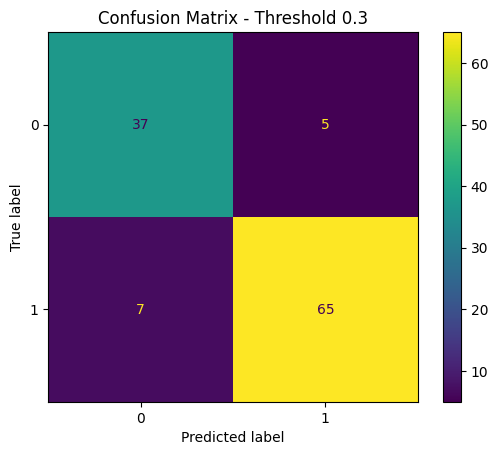

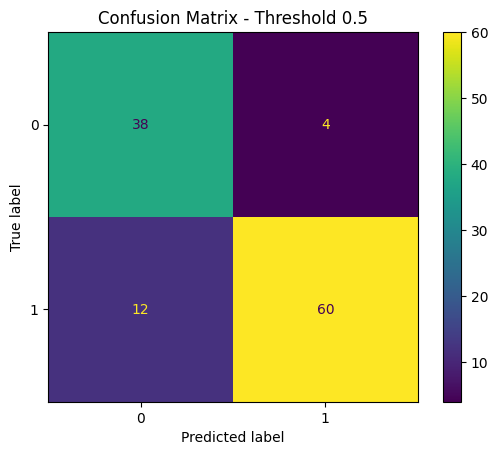

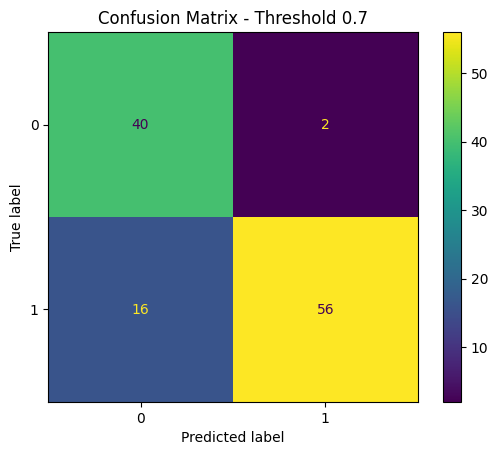

In [15]:
disp_03 = ConfusionMatrixDisplay(confusion_matrix=cm_03)
disp_03.plot()
plt.title("Confusion Matrix - Threshold 0.3")
plt.show()

disp_05 = ConfusionMatrixDisplay(confusion_matrix=cm_05)
disp_05.plot()
plt.title("Confusion Matrix - Threshold 0.5")
plt.show()

disp_07 = ConfusionMatrixDisplay(confusion_matrix=cm_07)
disp_07.plot()
plt.title("Confusion Matrix - Threshold 0.7")
plt.show()

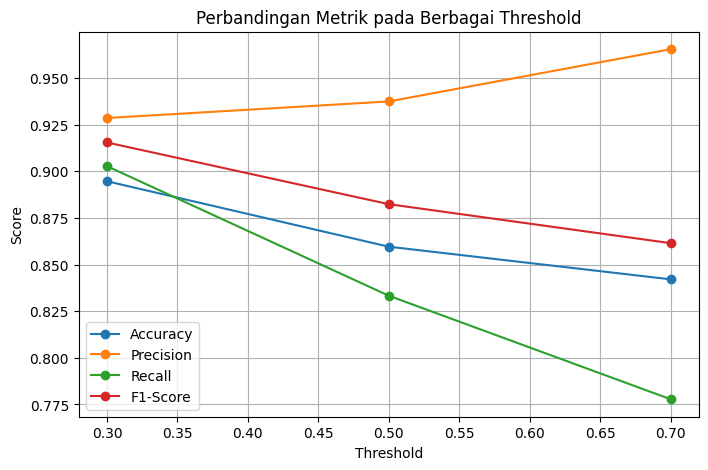

In [16]:
plt.figure(figsize=(8, 5))
plt.plot(results_df["Threshold"], results_df["Accuracy"], marker='o', label="Accuracy")
plt.plot(results_df["Threshold"], results_df["Precision"], marker='o', label="Precision")
plt.plot(results_df["Threshold"], results_df["Recall"], marker='o', label="Recall")
plt.plot(results_df["Threshold"], results_df["F1-Score"], marker='o', label="F1-Score")
plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Perbandingan Metrik pada Berbagai Threshold")
plt.legend()
plt.grid(True)
plt.show()

## **Model Logistic Regression tanpa melakukan scaling**

In [17]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix,
    classification_report,
    ConfusionMatrixDisplay
)

In [18]:
model_no_scaling = LogisticRegression(random_state=42, max_iter=1000)
model_no_scaling.fit(X_train, y_train)

LogisticRegression(max_iter=1000, random_state=42)

In [19]:
y_prob_no_scaling = model_no_scaling.predict_proba(X_test)[:, 1]

In [20]:
threshold = 0.5
y_pred_no_scaling = (y_prob_no_scaling >= threshold).astype(int)

In [21]:
acc_no_scaling = accuracy_score(y_test, y_pred_no_scaling)
prec_no_scaling = precision_score(y_test, y_pred_no_scaling, zero_division=0)
rec_no_scaling = recall_score(y_test, y_pred_no_scaling, zero_division=0)
f1_no_scaling = f1_score(y_test, y_pred_no_scaling, zero_division=0)
auc_no_scaling = roc_auc_score(y_test, y_prob_no_scaling)
cm_no_scaling = confusion_matrix(y_test, y_pred_no_scaling)

print("Hasil evaluasi Logistic Regression tanpa scaling")
print("Threshold :", threshold)
print("Accuracy  :", acc_no_scaling)
print("Precision :", prec_no_scaling)
print("Recall    :", rec_no_scaling)
print("F1-Score  :", f1_no_scaling)
print("ROC-AUC   :", auc_no_scaling)

print("\nConfusion Matrix:")
print(cm_no_scaling)

print("\nClassification Report:")
print(classification_report(y_test, y_pred_no_scaling, zero_division=0))

Hasil evaluasi Logistic Regression tanpa scaling
Threshold : 0.5
Accuracy  : 0.9035087719298246
Precision : 0.9552238805970149
Recall    : 0.8888888888888888
F1-Score  : 0.920863309352518
ROC-AUC   : 0.970568783068783

Confusion Matrix:
[[39  3]
 [ 8 64]]

Classification Report:
              precision    recall  f1-score   support

           0       0.83      0.93      0.88        42
           1       0.96      0.89      0.92        72

    accuracy                           0.90       114
   macro avg       0.89      0.91      0.90       114
weighted avg       0.91      0.90      0.90       114



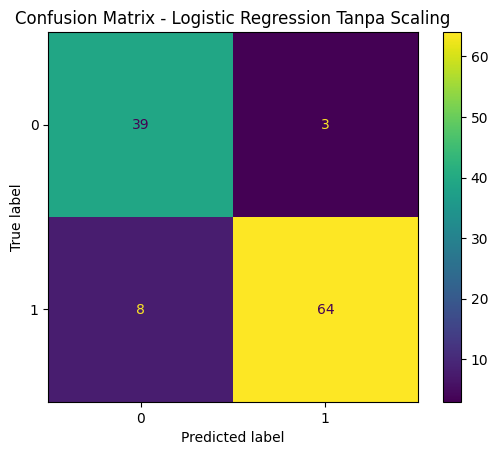

In [22]:
disp = ConfusionMatrixDisplay(confusion_matrix=cm_no_scaling)
disp.plot()
plt.title("Confusion Matrix - Logistic Regression Tanpa Scaling")
plt.show()

## **Perbandingan model dengan scaling dan tanpa scaling**

In [25]:
comparison_df = pd.DataFrame({
    "Model": ["Tanpa Scaling", "Dengan Scaling"],
    "Threshold": [threshold, threshold_05],
    "Accuracy": [acc_no_scaling, acc_05],
    "Precision": [prec_no_scaling, prec_05],
    "Recall": [rec_no_scaling, rec_05],
    "F1-Score": [f1_no_scaling, f1_05],
    "ROC-AUC": [auc_no_scaling, auc_05]
})

comparison_df = comparison_df.round(4)

print("Tabel perbandingan model")
print(comparison_df)

Tabel perbandingan model
            Model  Threshold  Accuracy  Precision  Recall  F1-Score  ROC-AUC
0   Tanpa Scaling        0.5    0.9035     0.9552  0.8889    0.9209   0.9706
1  Dengan Scaling        0.5    0.8596     0.9375  0.8333    0.8824   0.9719


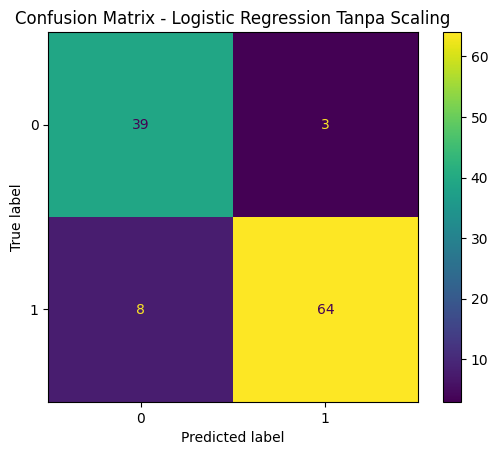

In [26]:
disp1 = ConfusionMatrixDisplay(confusion_matrix=cm_no_scaling)
disp1.plot()
plt.title("Confusion Matrix - Logistic Regression Tanpa Scaling")
plt.show()

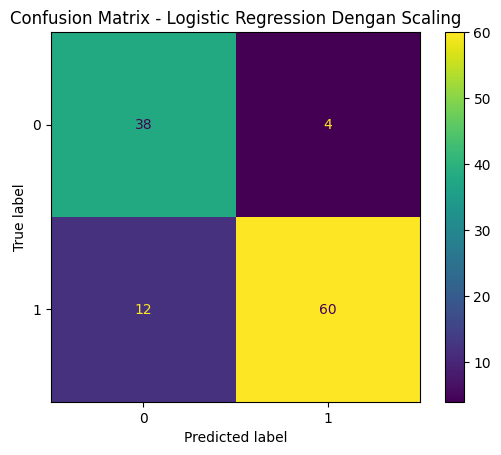

In [27]:
disp2 = ConfusionMatrixDisplay(confusion_matrix=cm_05)
disp2.plot()
plt.title("Confusion Matrix - Logistic Regression Dengan Scaling")
plt.show()

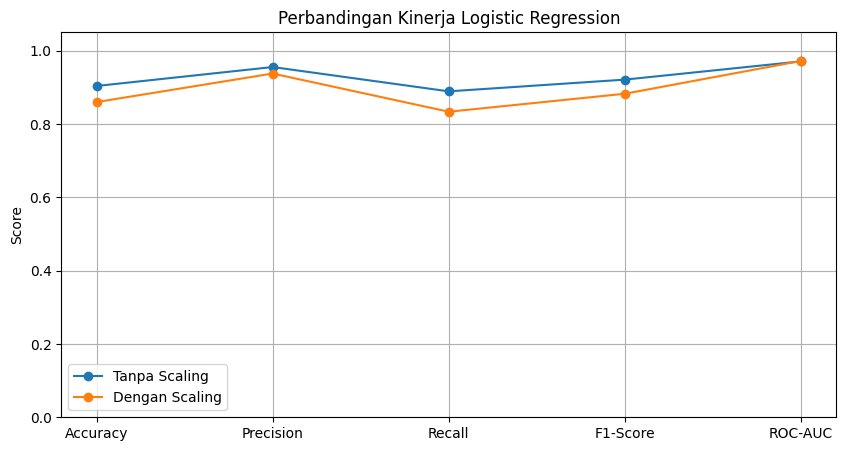

In [28]:
metrics_to_plot = ["Accuracy", "Precision", "Recall", "F1-Score", "ROC-AUC"]

plt.figure(figsize=(10, 5))
for model_name in comparison_df["Model"]:
    row = comparison_df[comparison_df["Model"] == model_name].iloc[0]
    plt.plot(metrics_to_plot, [row[m] for m in metrics_to_plot], marker='o', label=model_name)

plt.title("Perbandingan Kinerja Logistic Regression")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.grid(True)
plt.legend()
plt.show()